# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics
from scipy.stats import loguniform
from numpy.random import randint
from numpy.random import random_integers






pd.set_option('display.max_columns', None)

df = pd.read_csv('willenscharen.csv', encoding='latin1', delimiter = ',', index_col = 0)
df = df.backfill(axis=0)
df = df.ffill(axis=0)

# Sampling


**Convert to Array and create the samples as desired**

In [2]:
three_d = 15*3*24

df_list = df.values.tolist()
df_list_flat_x = [cell for row in df_list for cell in row]
df_list_flat_y = df_list_flat_x[13::15]

df_x_arr = []
df_y_arr = []



for i in range(70000):
  df_x_arr.append(df_list_flat_x[i*15:i*15 + three_d])
### Convert to Array and create the features as desired

for i in range(70000):
  df_y_arr.append(df_list_flat_y[i + 72:i + 96])

**Convert back to pandas structure**


In [3]:
df_x = pd.DataFrame(df_x_arr)
df_y = pd.DataFrame(df_y_arr)

**Restore the naming**


In [4]:
df_x_rename = df_x
### Convert back to pandas structure

df_x_rename['date'] = df.iloc[0:70000].index
df_x_rename = df_x_rename.set_index(['date'])
df_x_rename.index = pd.to_datetime(df_x_rename.index)


for i in range(0, 1066, 15):
    df_x_rename = df_x_rename.rename(columns={
        df_x_rename.columns[i + 0]: "bfwls+" + str(i/15),
        df_x_rename.columns[i + 1]: "LDIz+" + str(i/15),
        df_x_rename.columns[i + 2]: "LTPad+" + str(i/15),
        df_x_rename.columns[i + 3]: "LFPad+" + str(i/15),
        df_x_rename.columns[i + 4]: "QPad+" + str(i/15),
        df_x_rename.columns[i + 5]: "WPad+" + str(i/15),
        df_x_rename.columns[i + 6]: "NPad+" + str(i/15),
        df_x_rename.columns[i + 7]: "QSarl+" + str(i/15),
        df_x_rename.columns[i + 8]: "WSarl+" + str(i/15),
        df_x_rename.columns[i + 9]: "QWill+" + str(i/15),
        df_x_rename.columns[i + 10]: "ObereStoer+" + str(i/15),
        df_x_rename.columns[i + 11]: "Buenzau+" + str(i/15),
        df_x_rename.columns[i + 12]: "Aalbek+" + str(i/15),
        df_x_rename.columns[i + 13]: "Willenscharen_pegel_cm+" + str(i/15),
        df_x_rename.columns[i + 14]: "Willenscharen_radar_mm+" + str(i/15)
           })
    
df_x_final = df_x_rename

In [5]:
df_y_rename = df_y

df_y_rename['date'] = df.iloc[0:70000].index
df_y_rename = df_y_rename.set_index(['date'])
df_y_rename.index = pd.to_datetime(df_y_rename.index)


df_y_final = df_y_rename

**Output the samples**

In [6]:
df_x_final

bfwls+0.0     LDIz+0.0  LTPad+0.0  LFPad+0.0  QPad+0.0  \
date                                                                          
2014-01-01 02:00:00      106.0  1006.100000   2.600000  81.000000  2.430145   
2014-01-01 03:00:00      106.0  1006.000000   2.400000  81.000000  2.430618   
2014-01-01 04:00:00      106.0  1005.700000   1.900000  82.000000  2.431092   
2014-01-01 05:00:00      106.0  1005.400000   2.000000  79.000000  2.431566   
2014-01-01 06:00:00      106.0  1005.400000   1.700000  81.000000  2.432040   
...                        ...          ...        ...        ...       ...   
2021-12-29 22:00:00      105.0  1001.166667   3.833333  99.125000  1.722833   
2021-12-29 23:00:00      105.0  1001.133333   4.383333  99.250000  1.722833   
2021-12-30 00:00:00      107.0  1001.400000   4.725000  98.708333  1.722833   
2021-12-30 01:00:00      107.0  1001.716667   5.250000  98.766667  1.724873   
2021-12-30 02:00:00      107.0  1002.683333   5.800000  98.966667  1.724873   

                     WPad+0.0  NPad+0.0  QSarl+0.0  WSarl+0.0  QWill+0.0  \
date                                                                       
2014-01-01 02:00:00      37.0      0.00   3.377365   496.3000   7.259696   
2014-01-01 03:00:00      37.0      0.00   3.372238   496.2000   7.259495   
2014-01-01 04:00:00      37.0      0.00   3.361893   496.0001   7.259293   
2014-01-01 05:00:00      37.0      0.00   3.351543   495.8001   7.259092   
2014-01-01 06:00:00      37.0      0.00   3.335968   495.5001   7.258890   
...                       ...       ...        ...        ...        ...   
2021-12-29 22:00:00      33.0      0.00   2.081242   467.0000   4.767426   
2021-12-29 23:00:00      33.0      0.39   2.124941   468.0000   4.767426   
2021-12-30 00:00:00      33.0      0.30   2.124941   468.0000   4.872989   
2021-12-30 01:00:00      33.0      0.13   2.169457   469.0000   4.872989   
2021-12-30 02:00:00      33.0      0.01   2.214737   470.0000   4.978873   

                     ObereStoer+0.0  Buenzau+0.0  Aalbek+0.0  \
date                                                           
2014-01-01 02:00:00             0.0          0.0         0.0   
2014-01-01 03:00:00             0.0          0.0         0.0   
2014-01-01 04:00:00             0.0          0.0         0.0   
2014-01-01 05:00:00             0.0          0.0         0.0   
2014-01-01 06:00:00             0.0          0.0         0.0   
...                             ...          ...         ...   
2021-12-29 22:00:00             0.0          0.0         0.0   
2021-12-29 23:00:00             0.0          0.0         0.0   
2021-12-30 00:00:00             0.0          0.0         0.0   
2021-12-30 01:00:00             0.0          0.0         0.0   
2021-12-30 02:00:00             0.0          0.0         0.0   

                     Willenscharen_pegel_cm+0.0  Willenscharen_radar_mm+0.0  \
date                                                                          
2014-01-01 02:00:00                       182.0                         0.0   
2014-01-01 03:00:00                       182.0                         0.0   
2014-01-01 04:00:00                       182.0                         0.0   
2014-01-01 05:00:00                       182.0                         0.0   
2014-01-01 06:00:00                       182.0                         0.0   
...                                         ...                         ...   
2021-12-29 22:00:00                       161.0                         0.0   
2021-12-29 23:00:00                       161.0                         0.0   
2021-12-30 00:00:00                       162.0                         0.0   
2021-12-30 01:00:00                       162.0                         0.0   
2021-12-30 02:00:00                       163.0                         0.0   

                     bfwls+1.0     LDIz+1.0  LTPad+1.0  LFPad+1.0  QPad+1.0  \
date                                                            

In [7]:
df_y_final

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-01 02:00:00,182.0,182.0,183.0,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0
2014-01-01 03:00:00,182.0,183.0,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0
2014-01-01 04:00:00,183.0,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0
2014-01-01 05:00:00,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,183.0
2014-01-01 06:00:00,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,183.0,183.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-29 22:00:00,241.0,239.0,237.0,235.0,234.0,232.0,232.0,231.0,231.0,231.0,232.0,233.0,235.0,239.0,243.0,246.0,250.0,254.0,259.0,264.0,267.0,270.0,272.0,275.0
2021-12-29 23:00:00,239.0,237.0,235.0,234.0,232.0,232.0,231.0,231.0,231.0,232.0,233.0,235.0,239.0,243.0,246.0,250.0,254.0,259.0,264.0,267.0,270.0,272.0,275.0,277.0
2021-12-30 00:00:00,237.0,235.0,234.0,232.0,232.0,231.0,231.0,231.0,232.0,233.0,235.0,239.0,243.0,246.0,250.0,254.0,259.0,264.0,267.0,270.0,272.0,275.0,277.0,278.0


# Standardization


In [8]:
standardScaler = preprocessing.StandardScaler()
standardizedData = standardScaler.fit_transform(df_x_final)
df_x_final = pd.DataFrame(standardizedData, columns=df_x_final.columns, index=df_x_final.index)

# Dimensionality Reduction (using PCA)

**Creating a PCA with 60 components**

In [9]:
from sklearn.decomposition import PCA as sklearnPCA
pca = sklearnPCA(n_components=60)

model = pca.fit(df_x_final)
pcaTransformedData = model.transform(df_x_final)

# Hyperparameter Optimization Grid

**Split Training and Test Data**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
     pcaTransformedData, df_y_final, test_size=0.2, random_state=42)

**Hyperparameter Optimization using Grid Search (number of neurons, learning_rate, activation_function)**

In [11]:
regressor = MLPRegressor(alpha=0.0, 
                         batch_size=200, 
                         max_iter=1000, 
                         tol=0.0001,
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True, 
                         )


params = [{'hidden_layer_sizes': [(60, 40), (120, 80), (240, 160)],
         'learning_rate_init': [0.001, 0.005, 0.010],
         'activation': ['logistic', 'tanh', 'relu']}]

grid_search = GridSearchCV(regressor,
                      param_grid=params,
                      scoring='neg_root_mean_squared_error',
                      cv=[(slice(None), slice(None))],
                      n_jobs=-1)

grid_search.fit(X_train, y_train)
grid_search.best_params_


Iteration 1, loss = 11955.87045580
Validation score: -13.641794
Iteration 2, loss = 6844.08571674
Validation score: -7.300734
Iteration 3, loss = 3836.41256096
Validation score: -3.579525
Iteration 4, loss = 2126.42023825
Validation score: -1.563753
Iteration 5, loss = 1244.42871656
Validation score: -0.593083
Iteration 6, loss = 844.10323308
Validation score: -0.170244
Iteration 7, loss = 632.90287994
Validation score: 0.109847
Iteration 8, loss = 501.99263970
Validation score: 0.284048
Iteration 9, loss = 410.45396855
Validation score: 0.412931
Iteration 10, loss = 339.76087741
Validation score: 0.515065
Iteration 11, loss = 282.40111791
Validation score: 0.598326
Iteration 12, loss = 235.32617835
Validation score: 0.666486
Iteration 13, loss = 196.50103093
Validation score: 0.722298
Iteration 14, loss = 164.51525822
Validation score: 0.768155
Iteration 15, loss = 138.09093489
Validation score: 0.806643
Iteration 16, loss = 116.05848855
Validation score: 0.837992
Iteration 17, loss =

{'activation': 'logistic',
 'hidden_layer_sizes': (240, 160),
 'learning_rate_init': 0.001}

In [12]:
grid_search.best_params_

{'activation': 'logistic',
 'hidden_layer_sizes': (240, 160),
 'learning_rate_init': 0.001}

In [13]:
df_results = pd.DataFrame({'Params': grid_search.cv_results_['params'], 'Score': grid_search.cv_results_['mean_test_score']})
df_results

,Params,Score
0,"{'activation': 'logistic', 'hidden_layer_sizes...",-2.489894
1,"{'activation': 'logistic', 'hidden_layer_sizes...",-2.445620
2,"{'activation': 'logistic', 'hidden_layer_sizes...",-2.938848
3,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.686768
4,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.691703
5,"{'activation': 'logistic', 'hidden_layer_sizes...",-2.347610
6,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.340208
7,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.474558
8,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.909946
9,"{'activation': 'tanh', 'hidden_layer_sizes': (...",-2.598146


For the **activation function** we get the best results with a **tanh** function by quite a bit. 
Regarding the **number of neurons**, more is better but the improvements get smaller as the number of neurons increase so **(240, 160)** seems like a good tradeoff in regards to runtime vs results.
Similarly for the **learning rate**, less is better but the improvement from going to 0.001 is very negligible so similarly we'll stick with **0.005** for a better runtime. 

**Hyperparameter Optimization using Grid Search (alpha, momentum, batch_size)**

In [14]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         learning_rate_init=0.005,
                         max_iter=1000, 
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic')


params = [{'alpha': [0.1, 0.005, 0.0025],
         'momentum': [0.92, 0.95, 0.97],
          'batch_size':[100, 200, 300]}]

grid_search_2 = GridSearchCV(regressor,
                      param_grid=params,
                      scoring='neg_root_mean_squared_error',
                      cv=[(slice(None), slice(None))],
                      n_jobs=-1)

grid_search_2.fit(X_train, y_train)
grid_search_2.best_params_


Iteration 1, loss = 5303.59483850
Validation score: -0.539089
Iteration 2, loss = 573.80691344
Validation score: 0.425603
Iteration 3, loss = 265.64230529
Validation score: 0.694674
Iteration 4, loss = 151.06927691
Validation score: 0.817190
Iteration 5, loss = 95.12540047
Validation score: 0.880752
Iteration 6, loss = 63.79544218
Validation score: 0.917510
Iteration 7, loss = 44.96386055
Validation score: 0.938173
Iteration 8, loss = 33.13434621
Validation score: 0.952865
Iteration 9, loss = 25.63008537
Validation score: 0.960493
Iteration 10, loss = 20.70765740
Validation score: 0.967393
Iteration 11, loss = 17.00903681
Validation score: 0.970711
Iteration 12, loss = 14.70751775
Validation score: 0.974796
Iteration 13, loss = 12.98795909
Validation score: 0.976825
Iteration 14, loss = 11.86836383
Validation score: 0.979031
Iteration 15, loss = 10.77852545
Validation score: 0.980690
Iteration 16, loss = 9.71208264
Validation score: 0.982395
Iteration 17, loss = 8.69229612
Validation s

{'alpha': 0.0025, 'batch_size': 200, 'momentum': 0.95}

In [15]:
grid_search_2.best_params_

{'alpha': 0.0025, 'batch_size': 200, 'momentum': 0.95}

In [16]:
df_results_2 = pd.DataFrame({'Params': grid_search_2.cv_results_['params'], 'Score': grid_search_2.cv_results_['mean_test_score']})
df_results_2

,Params,Score
0,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-2.043685
1,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.515686
2,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.678702
3,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.395848
4,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.381009
5,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.413014
6,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.282405
7,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.476096
8,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.422513
9,"{'alpha': 0.005, 'batch_size': 100, 'momentum'...",-1.597762


For the **batch size**, bigger generally gives better results (but takes longer). A batch size of **200** appears to be sufficiently good.

For the regularization a value of **0.005** appears to give good results. More or less is worse. 

For the momentum again, a value of around **0.95** appears to be best.

**Hyperparameter Optimization using Grid Search (alpha, momentum, batch_size) with cv=5**

In [17]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         learning_rate_init=0.005,
                         max_iter=1000, 
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic')


params = [{'alpha': [0.1, 0.005, 0.0025],
         'momentum': [0.92, 0.95, 0.97],
          'batch_size':[100, 200, 300]}]

grid_search_2_cv = GridSearchCV(regressor,
                      param_grid=params,
                      scoring='neg_root_mean_squared_error',
                      cv=[(slice(None), slice(None))],
                      n_jobs=-1)

grid_search_2_cv.fit(X_train, y_train)
grid_search_2_cv.best_params_

Iteration 1, loss = 7170.88759405
Validation score: -2.619540
Iteration 2, loss = 1123.48479089
Validation score: -0.028636
Iteration 3, loss = 478.55282375
Validation score: 0.412518
Iteration 4, loss = 295.41519556
Validation score: 0.617452
Iteration 5, loss = 197.88551753
Validation score: 0.735850
Iteration 6, loss = 139.59785965
Validation score: 0.807971
Iteration 7, loss = 102.50295121
Validation score: 0.857449
Iteration 8, loss = 77.39144853
Validation score: 0.891771
Iteration 9, loss = 59.69752919
Validation score: 0.914063
Iteration 10, loss = 47.07883170
Validation score: 0.932704
Iteration 11, loss = 37.71202047
Validation score: 0.945268
Iteration 12, loss = 30.94913927
Validation score: 0.954606
Iteration 13, loss = 25.92329138
Validation score: 0.961181
Iteration 14, loss = 22.19156106
Validation score: 0.966601
Iteration 15, loss = 19.10833932
Validation score: 0.970720
Iteration 16, loss = 16.79683739
Validation score: 0.973451
Iteration 17, loss = 14.98824677
Valid

{'alpha': 0.0025, 'batch_size': 300, 'momentum': 0.95}

In [18]:
grid_search_2_cv.best_params_

{'alpha': 0.0025, 'batch_size': 300, 'momentum': 0.95}

In [19]:
df_results_3 = pd.DataFrame({'Params': grid_search_2_cv.cv_results_['params'], 'Score': grid_search_2_cv.cv_results_['mean_test_score']})
df_results_3

,Params,Score
0,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.517022
1,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.619511
2,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.639657
3,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.344861
4,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.520017
5,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.329348
6,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.417457
7,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.485492
8,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.352630
9,"{'alpha': 0.005, 'batch_size': 100, 'momentum'...",-1.602656


With a 5 Cross Validations the **resulting errors vary a lot less** (probably since the first random test set is less important). Thus all the **values are much closer together**. 

For the batch size not much has changed. 

For the **regularization** we now get better results with **0.0025**.

For the momentum we get best results with **0.97** now. 

In general, the parameters are much closer to each other then before though.

# Hyperparameter Optimization Random

**Hyperparameter Optimization using Random Search (alpha, momentum, batch_size)**

In [20]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         learning_rate_init=0.005,
                         max_iter=1000, 
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic')

# define search space
space = dict()
space['alpha'] = loguniform(0.001, 0.100)
space['momentum'] = loguniform(0.50, 0.99)
space['batch_size'] = list(range(50, 350))




random_search_1 = RandomizedSearchCV(regressor, 
                            space, 
                            n_iter=27, 
                            scoring='neg_root_mean_squared_error', 
                            n_jobs=-1, 
                            cv=[(slice(None), slice(None))], 
                            random_state=42)

random_search_1.fit(X_train, y_train)
random_search_1.best_params_


Iteration 1, loss = 6364.80026907
Validation score: -1.538984
Iteration 2, loss = 840.37733816
Validation score: 0.192962
Iteration 3, loss = 380.57398369
Validation score: 0.543245
Iteration 4, loss = 227.72698451
Validation score: 0.711617
Iteration 5, loss = 148.32008895
Validation score: 0.805468
Iteration 6, loss = 102.75565087
Validation score: 0.862591
Iteration 7, loss = 73.93072644
Validation score: 0.899318
Iteration 8, loss = 54.81703098
Validation score: 0.924167
Iteration 9, loss = 41.99129574
Validation score: 0.940212
Iteration 10, loss = 33.04269228
Validation score: 0.952895
Iteration 11, loss = 26.67565812
Validation score: 0.960779
Iteration 12, loss = 22.12410470
Validation score: 0.966661
Iteration 13, loss = 18.48197814
Validation score: 0.972078
Iteration 14, loss = 15.67929251
Validation score: 0.975471
Iteration 15, loss = 13.61780391
Validation score: 0.978203
Iteration 16, loss = 12.11880226
Validation score: 0.980415
Iteration 17, loss = 10.80060297
Validati

{'alpha': 0.007934293594590592,
 'batch_size': 251,
 'momentum': 0.9213701338139939}

In [21]:
random_search_1.best_params_

{'alpha': 0.007934293594590592,
 'batch_size': 251,
 'momentum': 0.9213701338139939}

In [22]:
df_results_4 = pd.DataFrame({'Params': random_search_1.cv_results_['params'], 'Score': random_search_1.cv_results_['mean_test_score']})
df_results_4

,Params,Score
0,"{'alpha': 0.005611516415334503, 'batch_size': ...",-1.424344
1,"{'alpha': 0.015751320499779724, 'batch_size': ...",-1.458098
2,"{'alpha': 0.0015847101210439089, 'batch_size':...",-1.344565
3,"{'alpha': 0.0019307837536547132, 'batch_size':...",-1.406134
4,"{'alpha': 0.0870602087830485, 'batch_size': 34...",-1.432472
5,"{'alpha': 0.09647685075720096, 'batch_size': 2...",-1.301105
6,"{'alpha': 0.011207606211860567, 'batch_size': ...",-1.301771
7,"{'alpha': 0.011208547084229366, 'batch_size': ...",-1.584945
8,"{'alpha': 0.08861577452533069, 'batch_size': 3...",-1.459038
9,"{'alpha': 0.03718364180573207, 'batch_size': 1...",-1.369757


**Hyperparameter Optimization using Random Search (alpha, momentum, batch_size) with cv=5**

In [23]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         learning_rate_init=0.005,
                         max_iter=1000, 
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic')

# define search space
space = dict()
space['alpha'] = loguniform(0.001, 0.100)
space['momentum'] = loguniform(0.50, 0.99)
space['batch_size'] = list(range(50, 350))




random_search_2 = RandomizedSearchCV(regressor, 
                            space, 
                            n_iter=27, 
                            scoring='accuracy', 
                            n_jobs=-1, 
                            cv=5, 
                            random_state=42)

random_search_2.fit(X_train, y_train)
random_search_2.best_params_


F:\Anaconda\envs\ITS\lib\site-packages\sklearn\model_selection\_search.py:972: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  category=UserWarning,


Iteration 1, loss = 7463.81484859
Validation score: -2.986660
Iteration 2, loss = 1264.43858985
Validation score: -0.138208
Iteration 3, loss = 519.78479900
Validation score: 0.349319
Iteration 4, loss = 317.69453580
Validation score: 0.566306
Iteration 5, loss = 214.58021132
Validation score: 0.695135
Iteration 6, loss = 152.46822907
Validation score: 0.776316
Iteration 7, loss = 112.69887842
Validation score: 0.830723
Iteration 8, loss = 85.65716756
Validation score: 0.870199
Iteration 9, loss = 66.43998479
Validation score: 0.897628
Iteration 10, loss = 52.43479669
Validation score: 0.918870
Iteration 11, loss = 42.20138198
Validation score: 0.933756
Iteration 12, loss = 34.72202320
Validation score: 0.946144
Iteration 13, loss = 28.91294427
Validation score: 0.954951
Iteration 14, loss = 24.68885945
Validation score: 0.959726
Iteration 15, loss = 21.26871778
Validation score: 0.966407
Iteration 16, loss = 18.57486516
Validation score: 0.969862
Iteration 17, loss = 16.61005855
Valid

{'alpha': 0.005611516415334503,
 'batch_size': 320,
 'momentum': 0.824379391412983}

In [24]:
random_search_2.best_params_

{'alpha': 0.005611516415334503,
 'batch_size': 320,
 'momentum': 0.824379391412983}

In [26]:
df_results_6 = pd.DataFrame({'Params': random_search_2.cv_results_['params'], 'Score': random_search_2.cv_results_['mean_test_score']})
df_results_6

,Params,Score
0,"{'alpha': 0.005611516415334503, 'batch_size': ...",NaN
1,"{'alpha': 0.015751320499779724, 'batch_size': ...",NaN
2,"{'alpha': 0.0015847101210439089, 'batch_size':...",NaN
3,"{'alpha': 0.0019307837536547132, 'batch_size':...",NaN
4,"{'alpha': 0.0870602087830485, 'batch_size': 34...",NaN
5,"{'alpha': 0.09647685075720096, 'batch_size': 2...",NaN
6,"{'alpha': 0.011207606211860567, 'batch_size': ...",NaN
7,"{'alpha': 0.011208547084229366, 'batch_size': ...",NaN
8,"{'alpha': 0.08861577452533069, 'batch_size': 3...",NaN
9,"{'alpha': 0.03718364180573207, 'batch_size': 1...",NaN


# Neural Network (Multi Layer Perceptron)

In [27]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         alpha=0.0025, 
                         batch_size=250, 
                         learning_rate_init=0.005,
                         momentum=0.97,
                         max_iter=1000,
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic',
                         )


In [28]:
regressor.fit(X_train, y_train)

Iteration 1, loss = 6362.24124954
Validation score: -1.434295
Iteration 2, loss = 801.63275540
Validation score: 0.205305
Iteration 3, loss = 364.69751830
Validation score: 0.552404
Iteration 4, loss = 217.21258765
Validation score: 0.720037
Iteration 5, loss = 140.88202473
Validation score: 0.812145
Iteration 6, loss = 97.16972104
Validation score: 0.866371
Iteration 7, loss = 70.13255440
Validation score: 0.900331
Iteration 8, loss = 51.71590302
Validation score: 0.927132
Iteration 9, loss = 39.42516556
Validation score: 0.943086
Iteration 10, loss = 31.15646760
Validation score: 0.952846
Iteration 11, loss = 25.26354321
Validation score: 0.961840
Iteration 12, loss = 21.09471889
Validation score: 0.967481
Iteration 13, loss = 17.97309488
Validation score: 0.970500
Iteration 14, loss = 16.11604541
Validation score: 0.973961
Iteration 15, loss = 14.27065188
Validation score: 0.976278
Iteration 16, loss = 12.82915044
Validation score: 0.978819
Iteration 17, loss = 11.58457460
Validatio

MLPRegressor(activation='logistic', alpha=0.0025, batch_size=250,
             early_stopping=True, hidden_layer_sizes=(240, 160),
             learning_rate_init=0.005, max_iter=1000, momentum=0.97,
             verbose=True)

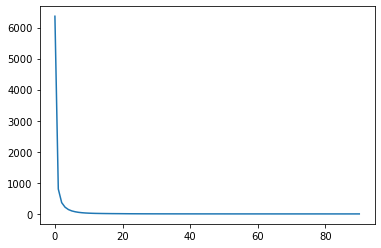

In [29]:
plt.plot(regressor.loss_curve_)

In [30]:
y_pred = regressor.predict(X_test)

In [31]:
np.sqrt(metrics.mean_squared_error(y_test,y_pred))

1.8695666693325705

In [32]:
y_test.stack().std()

35.986012320122036

In [33]:
y_test.stack().mean()

171.39827083333333

<AxesSubplot:xlabel='date'>

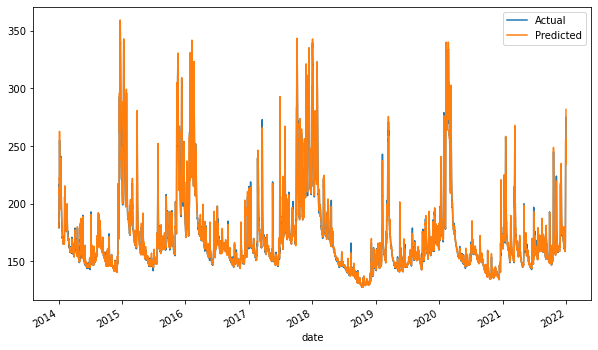

In [34]:
y_Pred = pd.DataFrame(y_pred, index=y_test.index)

df_temp = pd.DataFrame({'Actual': y_test[23], 'Predicted': y_Pred[23]})
df_temp = df_temp.sort_values(by="date")
df_temp.plot(figsize=(10,6))

<AxesSubplot:xlabel='date'>

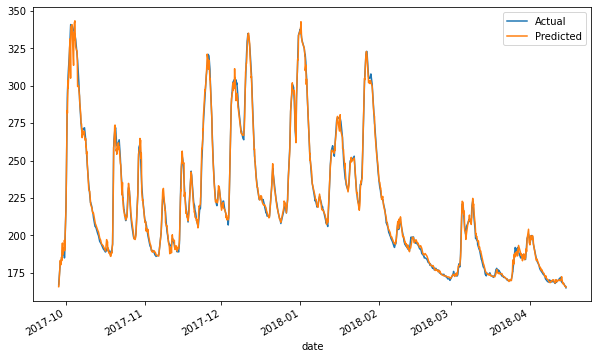

In [35]:
y_Pred = pd.DataFrame(y_pred, index=y_test.index)

df_temp = pd.DataFrame({'Actual': y_test[23], 'Predicted': y_Pred[23]})
df_temp = df_temp.sort_values(by="date")

df_temp.iloc[6500:7500].plot(figsize=(10,6))